# Superpixel Occlusion for radar sample visualization

Tento notebook je pripravený pre umiestnenie do **materského foldra** projektu `GradCamIntegration [DiplomaThesis]` podľa tvojej screenshot štruktúry.

Cieľ:
- načítať rovnaké radar dáta ako v `DetekciaOdpaduMiniProjekt/notebook_radar.ipynb`,
- spraviť inference cez ten istý model,
- aplikovať `SuperpixelOcclusion` na radar sample reprezentovaný ako 2D pseudo-obrázok *(feature × time)*,
- a vedľa každej feature vykresliť farebný štvorček, ktorý reprezentuje priemerný príspevok danej feature k predikovanej triede.

> Poznámka: `SuperpixelOcclusion` očakáva vstup tvaru `(1, C, H, W)`, preto je tu použitý malý **adapter model**, ktorý vie zabaliť radar sample do 4D vstupu a zároveň ho poslať do pôvodnej radar siete v správnom tvare.


In [1]:

# Ak by chýbala knižnica:
# %pip install scikit-image

import sys
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = Path.cwd()
PROJECT_DIR = ROOT / "DetekciaOdpaduMiniProjekt"
OCCLUSION_DIR = ROOT / "Occlusion"
GRADCAM_DIR = ROOT / "GradCAM"
IG_DIR = ROOT / "IntegratedGradients"

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
if str(OCCLUSION_DIR) not in sys.path:
    sys.path.insert(0, str(OCCLUSION_DIR))
if str(GRADCAM_DIR) not in sys.path:
    sys.path.insert(0, str(GRADCAM_DIR))
if str(IG_DIR) not in sys.path:
    sys.path.insert(0, str(IG_DIR))

print("ROOT:", ROOT)
print("PROJECT_DIR exists:", PROJECT_DIR.exists())
print("OCCLUSION_DIR exists:", OCCLUSION_DIR.exists())
print("GRADCAM_DIR exists:", GRADCAM_DIR.exists())


ROOT: C:\Users\tvysi\PycharmProjects\GradCamIntegration
PROJECT_DIR exists: True
OCCLUSION_DIR exists: True
GRADCAM_DIR exists: True


In [2]:

import SensorNormalizer, WindowedLeBasedDataset, TrainingRadar, Networks
from DataLoader import DataLoaderProprietary
import DataViewModel
from DataViewModel import LoadedDataViewModel

importlib.reload(WindowedLeBasedDataset)
importlib.reload(SensorNormalizer)
importlib.reload(TrainingRadar)
importlib.reload(Networks)

from SuperpixelOcclusion import SuperpixelOcclusion
from GradCAM import GradCAM1D
from IntegratedGradients import IntegratedGradients

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [3]:


loaded_data_view_model: LoadedDataViewModel = DataLoaderProprietary.load_all_data(
    load_from_csv_files=False,
    file_name=str(PROJECT_DIR / "final_dataset_nove_vozidla_2"),
    load_video_annotations=True
)

LoadedDataViewModel.add_dummy_messages(loaded_data_view_model.vehicles)

vehicle_split_commands = []
vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, "ZA196JN_video"))
vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, "ZA234JG_video"))
vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, "ZA503JU_video"))

loaded_data_view_model.normalizer = SensorNormalizer.SensorNormalizer(
    True,
    False,
    [
        "axis_x_acc",
        "axis_y_acc",
        "axis_z_acc",
        "sig_pwr",
    ]
)
if False:
    train_vehicles_ecv = ['ZA127IR', 'ZA234JG',  'ZA255KC', 'ZA346KA', 'ZA499JN']
    train_vehicles = []
    for vehicle in loaded_data_view_model.train_vehicles:
        if vehicle.ecv in train_vehicles_ecv:
            train_vehicles.append(vehicle)

loaded_data_view_model.split_to_train_and_test(vehicle_split_commands)

train_dataset = WindowedLeBasedDataset.WindowedLeBasedDataset(loaded_data_view_model.train_vehicles, 25 * 2, 'train', 25)
test_dataset = WindowedLeBasedDataset.WindowedLeBasedDataset(loaded_data_view_model.test_vehicles, 25 * 2, 'test', 25)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))


SensorNormalizer: ignore_rfid = False , use_left_right_arm_info = True , field_names = None
Bola spustena inicializacia dat
Celkovy pocet data messages : 0
Celkovy pocet vysypov: 0
split b les between car arms
remove bad les
Spustam nacitanie dat
Spúšťam načítanie loaded data viewmodelu
Nacitanie dokoncene
Pridavam dummy messages
Hotovo
SensorNormalizer: ignore_rfid = True , use_left_right_arm_info = False , field_names = ['axis_x_acc', 'axis_y_acc', 'axis_z_acc', 'sig_pwr']
Vozidlo s ecv: ZA127IR bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA234JG bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA255KC bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA346KA bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA499JN bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: AA619SP bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: AA713KN bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: BT155HT bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: BT874HR bolo zaradene do trenovac

In [4]:

patience = 50
train = False

FINAL_DROPOUT = 0.2
FINAL_WEIGHT_DECAY = 1e-3
FINAL_B1_MULTIPLIER = 3.0
FINAL_B2_MULTIPLIER = 5.0

model = Networks.CnnBaseNetworkRadar(10, 4, 50, dropout_rate=FINAL_DROPOUT)

trainer = TrainingRadar.TrainingRadar(
    model,
    str(PROJECT_DIR / "container_type_le_based_best"),
    1000,
    lr=3e-4,
    weight_decay=FINAL_WEIGHT_DECAY,
    device=device,
    class_weight_b1_multiplier=FINAL_B1_MULTIPLIER,
    class_weight_b2_multiplier=FINAL_B2_MULTIPLIER,
)

training_results = trainer.train(train_dataset, test_dataset, 4, train, patience, ["L", "R", "B1", "B2"])
model = training_results["model"]
model.eval()

print(type(model))


<class 'Networks.CnnBaseNetworkRadar'>


In [5]:

FEATURE_NAMES = ["axis_x_acc", "axis_y_acc", "axis_z_acc", "sig_pwr", "mask"]
CLASS_NAMES = ["L", "R", "B1", "B2"]

def extract_true_label(label):
    if torch.is_tensor(label):
        if label.numel() == 1:
            return int(label.item())
        return int(torch.argmax(label).item())
    return int(label)

def sample_to_feature_time(sample: torch.Tensor) -> torch.Tensor:
    """Returns tensor in shape [features, time]."""
    x = sample.detach().cpu()
    if x.dim() != 2:
        raise ValueError(f"Expected 2D sample, got shape {tuple(x.shape)}")
    if x.shape[0] > x.shape[1]:
        x = x.T
    return x

class RadarModelAdapter(nn.Module):
    """Wraps original radar model so SuperpixelOcclusion can work with 4D input.

    SuperpixelOcclusion calls model with (B, C, H, W).
    Original radar model in notebook appears to accept (B, H, W) or similar 3D tensor.
    This adapter squeezes channel dim when C == 1.
    """
    def __init__(self, base_model: nn.Module):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        if x.dim() != 4:
            raise ValueError(f"Expected 4D input (B,C,H,W), got {tuple(x.shape)}")
        if x.size(1) == 1:
            x = x.squeeze(1)  # -> (B, H, W)
        return self.base_model(x)

def make_input_4d_from_sample(sample: torch.Tensor) -> torch.Tensor:
    feature_time = sample_to_feature_time(sample)  # [F, T]
    return feature_time.unsqueeze(0).unsqueeze(0)  # [1, 1, F, T]

def feature_time_to_segmentation_rgb(feature_time: torch.Tensor) -> np.ndarray:
    """Create HxWx3 pseudo-RGB image from [features, time] for SLIC segmentation."""
    arr = feature_time.detach().cpu().numpy().astype(np.float32)
    mn, mx = float(arr.min()), float(arr.max())
    if mx - mn < 1e-8:
        norm = np.zeros_like(arr, dtype=np.float32)
    else:
        norm = (arr - mn) / (mx - mn)

    # Use 3 simple channels so SLIC sees structure in the sample:
    # ch0 = normalized value
    # ch1 = row-wise normalized deviation
    # ch2 = temporal gradient magnitude
    row_mean = norm.mean(axis=1, keepdims=True)
    row_std = norm.std(axis=1, keepdims=True) + 1e-8
    row_dev = np.clip((norm - row_mean) / row_std, -2.0, 2.0)
    row_dev = (row_dev + 2.0) / 4.0

    grad = np.abs(np.gradient(norm, axis=1))
    gmn, gmx = float(grad.min()), float(grad.max())
    if gmx - gmn < 1e-8:
        grad_norm = np.zeros_like(grad, dtype=np.float32)
    else:
        grad_norm = (grad - gmn) / (gmx - gmn)

    rgb = np.stack([norm, row_dev, grad_norm], axis=-1)
    return np.clip(rgb, 0.0, 1.0)

def run_model_on_sample(model, sample):
    input_3d = sample_to_feature_time(sample).unsqueeze(0).to(next(model.parameters()).device)
    with torch.no_grad():
        output = model(input_3d)
        probs = torch.softmax(output, dim=1)
        pred_class = int(torch.argmax(probs, dim=1).item())
        confidence = float(probs[0, pred_class].item())
    return output, probs, pred_class, confidence

def explain_sample_with_superpixel(
    model,
    sample,
    target_class=None,
    n_segments=24,
    compactness=0.25,
    sigma=0.8,
    occlusion_value="mean",
    mode="prob_drop",
    batch_size=32,
    keep_negative=False,
):
    feature_time = sample_to_feature_time(sample)
    input_4d = make_input_4d_from_sample(sample).to(next(model.parameters()).device)
    seg_rgb = feature_time_to_segmentation_rgb(feature_time)

    adapter = RadarModelAdapter(model).to(next(model.parameters()).device)
    explainer = SuperpixelOcclusion(adapter)

    feat_map, output, segment_drops, segments = explainer.explain(
        input_4d,
        target_class=target_class,
        segmentation_image=seg_rgb,
        segmentation="slic",
        n_segments=n_segments,
        compactness=compactness,
        sigma=sigma,
        occlusion_value=occlusion_value,
        mode=mode,
        batch_size=batch_size,
        keep_negative=keep_negative,
    )

    feat_map_2d = feat_map.squeeze().detach().cpu().numpy()  # [F, T]
    row_scores = feat_map_2d.mean(axis=1)

    # normalize row scores only for display
    rmin, rmax = float(row_scores.min()), float(row_scores.max())
    if rmax - rmin < 1e-8:
        row_scores_norm = np.zeros_like(row_scores)
    else:
        row_scores_norm = (row_scores - rmin) / (rmax - rmin)

    return {
        "feature_time": feature_time.detach().cpu().numpy(),
        "feat_map_2d": feat_map_2d,
        "row_scores": row_scores,
        "row_scores_norm": row_scores_norm,
        "output": output.detach().cpu(),
        "segment_drops": segment_drops.detach().cpu().numpy(),
        "segments": segments,
        "segmentation_rgb": seg_rgb,
    }

def plot_superpixel_debug_views(result, cmap="coolwarm"):
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), constrained_layout=True)

    axes[0].imshow(result["segmentation_rgb"], aspect="auto")
    axes[0].set_title("Pseudo-RGB image used for SLIC segmentation (feature × time)")
    axes[0].set_ylabel("Feature row")
    axes[0].set_xlabel("Time step")

    axes[1].imshow(result["segments"], aspect="auto")
    axes[1].set_title("SLIC segments")
    axes[1].set_ylabel("Feature row")
    axes[1].set_xlabel("Time step")

    im = axes[2].imshow(result["feat_map_2d"], aspect="auto", cmap=cmap)
    axes[2].set_title("Dense SuperpixelOcclusion attribution map")
    axes[2].set_ylabel("Feature row")
    axes[2].set_xlabel("Time step")
    plt.colorbar(im, ax=axes[2], label="Importance")
    plt.show()

def run_gradcam_sample(model, sample, target_layer, target_class=None):
    model.eval()
    device = next(model.parameters()).device

    if isinstance(sample, tuple):
        sample = sample[0]

    if not torch.is_tensor(sample):
        sample = torch.tensor(sample, dtype=torch.float32)

    # sample: [C, T] -> [1, C, T]
    input_tensor = sample.unsqueeze(0).to(device)

    explainer = GradCAM1D(model, target_layer)
    cam, output = explainer.explain(input_tensor, target_class=target_class)
    explainer.remove_hooks()

    probs = torch.softmax(output, dim=1)
    pred_class = int(torch.argmax(probs, dim=1).item())
    confidence = float(probs[0, pred_class].item())

    cam_1d = cam.squeeze(0).squeeze(0).detach().cpu().numpy()  # [T]

    if cam_1d.ndim != 1:
        raise ValueError(f"Expected 1D CAM over time, got shape {cam_1d.shape}")

    return cam_1d, pred_class, confidence, output

def run_ig_sample(model, sample, target_class=None, baseline=None, steps=50):
    model.eval()
    device = next(model.parameters()).device

    if isinstance(sample, tuple):
        sample = sample[0]

    if not torch.is_tensor(sample):
        sample = torch.tensor(sample, dtype=torch.float32)

    # sample: [C, T] -> [1, C, T]
    input_tensor = sample.unsqueeze(0).to(device)

    # target class
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_class = int(torch.argmax(probs, dim=1).item())
        confidence = float(probs[0, pred_class].item())

    if target_class is None:
        target_class = pred_class

    if baseline is not None:
        if not torch.is_tensor(baseline):
            baseline = torch.tensor(baseline, dtype=torch.float32)
        baseline = baseline.unsqueeze(0).to(device)  # [1, C, T]

    explainer = IntegratedGradients(model, device=device)
    ig = explainer.explain(
        inputs=input_tensor,
        target=target_class,
        baseline=baseline,
        steps=steps
    )

    # [1, C, T] -> [C, T]
    ig_2d = ig.squeeze(0).detach().cpu().numpy()

    if ig_2d.ndim != 2:
        raise ValueError(f"Expected IG map [C, T], got shape {ig_2d.shape}")

    return ig_2d, pred_class, confidence, output

def normalize_ig_map_per_feature(ig_map, use_abs=True):
    ig_map = np.asarray(ig_map, dtype=np.float32)

    if use_abs:
        vis = np.abs(ig_map)
    else:
        vis = ig_map.copy()

    out = np.zeros_like(vis)

    for i in range(vis.shape[0]):
        row = vis[i]
        rmin = float(row.min())
        rmax = float(row.max())

        if rmax - rmin < 1e-8:
            out[i] = 0.0
        else:
            out[i] = (row - rmin) / (rmax - rmin)

    return out

def prepare_ig_for_display(ig_map, use_abs=True, clip_percentile=98, eps=1e-8):
    ig_map = np.asarray(ig_map, dtype=np.float32)

    if use_abs:
        vis = np.abs(ig_map)
    else:
        vis = ig_map.copy()

    out = np.zeros_like(vis)

    for i in range(vis.shape[0]):
        row = vis[i]

        hi = np.percentile(row, clip_percentile)
        lo = 0.0

        row = np.clip(row, lo, hi)

        rmin = float(row.min())
        rmax = float(row.max())

        if rmax - rmin < eps:
            out[i] = 0.0
        else:
            out[i] = (row - rmin) / (rmax - rmin)

    return out

def smooth_heatmap_rows(x, kernel_size=3):
    x = np.asarray(x, dtype=np.float32)
    if kernel_size <= 1:
        return x

    pad = kernel_size // 2
    kernel = np.ones(kernel_size, dtype=np.float32) / kernel_size

    out = np.zeros_like(x)
    for i in range(x.shape[0]):
        row = np.pad(x[i], (pad, pad), mode="edge")
        out[i] = np.convolve(row, kernel, mode="valid")
    return out

def compute_explanation_map(
    method,
    model,
    sample,
    target_layer=None,
    target_class=None,
    baseline=None,
    steps=50,
):
    method = method.lower()

    if method == "gradcam":
        if target_layer is None:
            raise ValueError("target_layer is required for GradCAM")
        return run_gradcam_sample(model, sample, target_layer, target_class=target_class)

    if method == "ig":
        return run_ig_sample(
            model=model,
            sample=sample,
            target_class=target_class,
            baseline=baseline,
            steps=steps,
        )

    raise NotImplementedError(f"Method '{method}' is not implemented yet.")

def compute_grouped_ylims(feature_time, feature_names):
    ylims = {}
    lower_names = [str(name).lower() for name in feature_names]

    acc_idx = [
        i for i, name in enumerate(lower_names)
        if name in {"axis_x_acc", "axis_y_acc", "axis_z_acc"}
    ]

    if acc_idx:
        vals = feature_time[acc_idx, :]
        ymin = float(np.min(vals))
        ymax = float(np.max(vals))
        pad = 0.05 * max(ymax - ymin, 1e-8)
        shared = (ymin - pad, ymax + pad)
        for i in acc_idx:
            ylims[i] = shared

    for i in range(len(feature_names)):
        if i in ylims:
            continue
        vals = feature_time[i]
        ymin = float(np.min(vals))
        ymax = float(np.max(vals))
        pad = 0.05 * max(ymax - ymin, 1e-8)
        if ymax - ymin < 1e-8:
            pad = 0.1 if abs(ymax) < 1e-8 else 0.05 * abs(ymax)
        ylims[i] = (ymin - pad, ymax + pad)

    return ylims


In [6]:
def plot_time_series_explanations(
    feature_time,
    feature_scores=None,       # [C]
    feature_heatmaps=None,     # [C, T] napr. IG
    global_attribution=None,   # [T] napr. GradCAM
    true_label=None,
    pred_class=None,
    confidence=None,
    feature_names=None,
    class_names=None,
    feature_cmap="jet",
    heatmap_cmap="jet",
    global_cmap="jet",
    feature_label="Attribution strength (normalized)",
    global_title="GradCAM",
    figsize_per_feature=2.8,
):
    feature_time = np.asarray(feature_time, dtype=np.float32)

    if feature_scores is not None:
        feature_scores = np.asarray(feature_scores, dtype=np.float32)

    if feature_heatmaps is not None:
        feature_heatmaps = np.asarray(feature_heatmaps, dtype=np.float32)

    if global_attribution is not None:
        global_attribution = np.asarray(global_attribution, dtype=np.float32)

    feature_names = feature_names or [f"feature_{i}" for i in range(feature_time.shape[0])]
    num_features = min(feature_time.shape[0], len(feature_names))
    feature_time = feature_time[:num_features]

    if feature_scores is not None:
        if feature_scores.ndim != 1:
            raise ValueError(f"feature_scores must have shape [C], got {feature_scores.shape}")
        num_features = min(num_features, feature_scores.shape[0])
        feature_time = feature_time[:num_features]
        feature_scores = feature_scores[:num_features]

    if feature_heatmaps is not None:
        if feature_heatmaps.ndim != 2:
            raise ValueError(f"feature_heatmaps must have shape [C, T], got {feature_heatmaps.shape}")
        num_features = min(num_features, feature_heatmaps.shape[0])
        feature_time = feature_time[:num_features]
        feature_heatmaps = feature_heatmaps[:num_features]

    if global_attribution is not None:
        if global_attribution.ndim != 1:
            raise ValueError(f"global_attribution must have shape [T], got {global_attribution.shape}")

    ylims = compute_grouped_ylims(feature_time, feature_names[:num_features])

    pred_text = class_names[pred_class] if class_names and pred_class is not None and pred_class < len(class_names) else pred_class
    true_text = class_names[true_label] if class_names and true_label is not None and true_label < len(class_names) else true_label

    # Outer grid: one block per feature + optional bottom GradCAM row
    n_outer_rows = num_features + (1 if global_attribution is not None else 0)

    fig = plt.figure(
        figsize=(16, figsize_per_feature * num_features + (1.2 if global_attribution is not None else 0.0)),
        constrained_layout=True
    )

    outer = gridspec.GridSpec(
        nrows=n_outer_rows,
        ncols=4,
        figure=fig,
        width_ratios=[3.0, 1.0, 18.0, 0.9],
        height_ratios=[1.0] * num_features + ([0.7] if global_attribution is not None else []),
        hspace=0.18,
        wspace=0.08,
    )

    prev_ax_ts = None
    main_im = None

    # ----- Per-feature blocks -----
    for i in range(num_features):
        # Left label spans the whole feature block
        ax_name = fig.add_subplot(outer[i, 0])
        ax_name.axis("off")
        ax_name.text(
            0.98, 0.5, feature_names[i],
            ha="right", va="center", fontsize=11
        )

        # Feature score square
        ax_score = fig.add_subplot(outer[i, 1])
        if feature_scores is not None:
            score_img = np.array([[feature_scores[i]]], dtype=np.float32)
            ax_score.imshow(
                score_img,
                cmap=feature_cmap,
                vmin=0.0,
                vmax=1.0,
                aspect="auto",
                interpolation="nearest"
            )
        ax_score.set_xticks([])
        ax_score.set_yticks([])
        for spine in ax_score.spines.values():
            spine.set_visible(False)

        # Right side split into line + optional IG
        if feature_heatmaps is not None:
            sub = outer[i, 2].subgridspec(2, 1, height_ratios=[5.0, 1.2], hspace=0.02)
            ax_ts = fig.add_subplot(sub[0], sharex=prev_ax_ts)
            ax_hm = fig.add_subplot(sub[1], sharex=ax_ts)
        else:
            ax_ts = fig.add_subplot(outer[i, 2], sharex=prev_ax_ts)
            ax_hm = None

        # Main time series
        ax_ts.plot(feature_time[i], linewidth=1.9)
        ax_ts.set_ylim(*ylims[i])
        ax_ts.grid(True, alpha=0.28)
        ax_ts.margins(x=0, y=0.02)

        if i < num_features - 1 or global_attribution is not None:
            ax_ts.tick_params(axis="x", labelbottom=False)
        else:
            ax_ts.set_xlabel("Time step")

        # IG heatmap
        if ax_hm is not None:
            band_hm = np.repeat(feature_heatmaps[i][None, :], 12, axis=0)
            main_im = ax_hm.imshow(
                band_hm,
                aspect="auto",
                cmap=heatmap_cmap,
                vmin=0.0,
                vmax=1.0,
                interpolation="nearest",
                origin="lower"
            )
            ax_hm.set_yticks([])
            ax_hm.margins(x=0, y=0)
            if i < num_features - 1 or global_attribution is not None:
                ax_hm.tick_params(axis="x", labelbottom=False)
            else:
                ax_hm.set_xlabel("Time step")
            for spine in ax_hm.spines.values():
                spine.set_visible(False)

        prev_ax_ts = ax_ts

    # ----- Bottom shared GradCAM block -----
    if global_attribution is not None:
        row = num_features

        ax_global_name = fig.add_subplot(outer[row, 0:2])
        ax_global_name.axis("off")
        ax_global_name.text(
            0.98, 0.5, global_title,
            ha="right", va="center", fontsize=11, fontweight="bold"
        )

        ax_global = fig.add_subplot(outer[row, 2], sharex=prev_ax_ts)
        band_global = np.repeat(global_attribution[None, :], 10, axis=0)
        ax_global.imshow(
            band_global,
            aspect="auto",
            cmap=global_cmap,
            vmin=0.0,
            vmax=1.0,
            interpolation="nearest",
            origin="lower"
        )
        ax_global.set_yticks([])
        ax_global.set_xlabel("Time step")
        ax_global.margins(x=0)
        for spine in ax_global.spines.values():
            spine.set_visible(False)

    # Single legend only
    if main_im is None:
        # fallback if IG is not present
        dummy = np.repeat(np.array([[0.0, 1.0]], dtype=np.float32), 10, axis=0)
        ax_dummy = fig.add_subplot(outer[:num_features, 3])
        main_im = ax_dummy.imshow(dummy, aspect="auto", cmap=feature_cmap, vmin=0.0, vmax=1.0)
        ax_dummy.remove()

    cbar_ax = fig.add_subplot(outer[:num_features, 3])
    cbar = fig.colorbar(main_im, cax=cbar_ax)
    cbar.set_label(feature_label)

    title_parts = []
    if true_text is not None:
        title_parts.append(f"True: {true_text}")
    if pred_text is not None:
        title_parts.append(f"Pred: {pred_text}")
    if confidence is not None:
        title_parts.append(f"Conf: {confidence:.3f}")

    fig.suptitle(" | ".join(title_parts), fontsize=13)
    plt.show()

In [7]:
print(model)

target_layer = model.features[-1]

CnnBaseNetworkRadar(
  (features): Sequential(
    (0): Conv1d(10, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (classifier): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [8]:

sample_idx = 0
sample, label = train_dataset[sample_idx]

true_label = extract_true_label(label)
_, probs, pred_class, confidence = run_model_on_sample(model, sample)

print("Sample index:", sample_idx)
print("True label:", true_label, CLASS_NAMES[true_label] if true_label < len(CLASS_NAMES) else "")
print("Predicted class:", pred_class, CLASS_NAMES[pred_class] if pred_class < len(CLASS_NAMES) else "")
print("Confidence:", round(confidence, 4))
print("All probabilities:", probs[0].detach().cpu().numpy())


Sample index: 0
True label: 0 L
Predicted class: 0 L
Confidence: 0.9635
All probabilities: [0.9634756  0.00594648 0.00255594 0.02802199]


In [9]:
print(type(true_label))
print(true_label)
print(getattr(true_label, "shape", None))

<class 'int'>
0
None


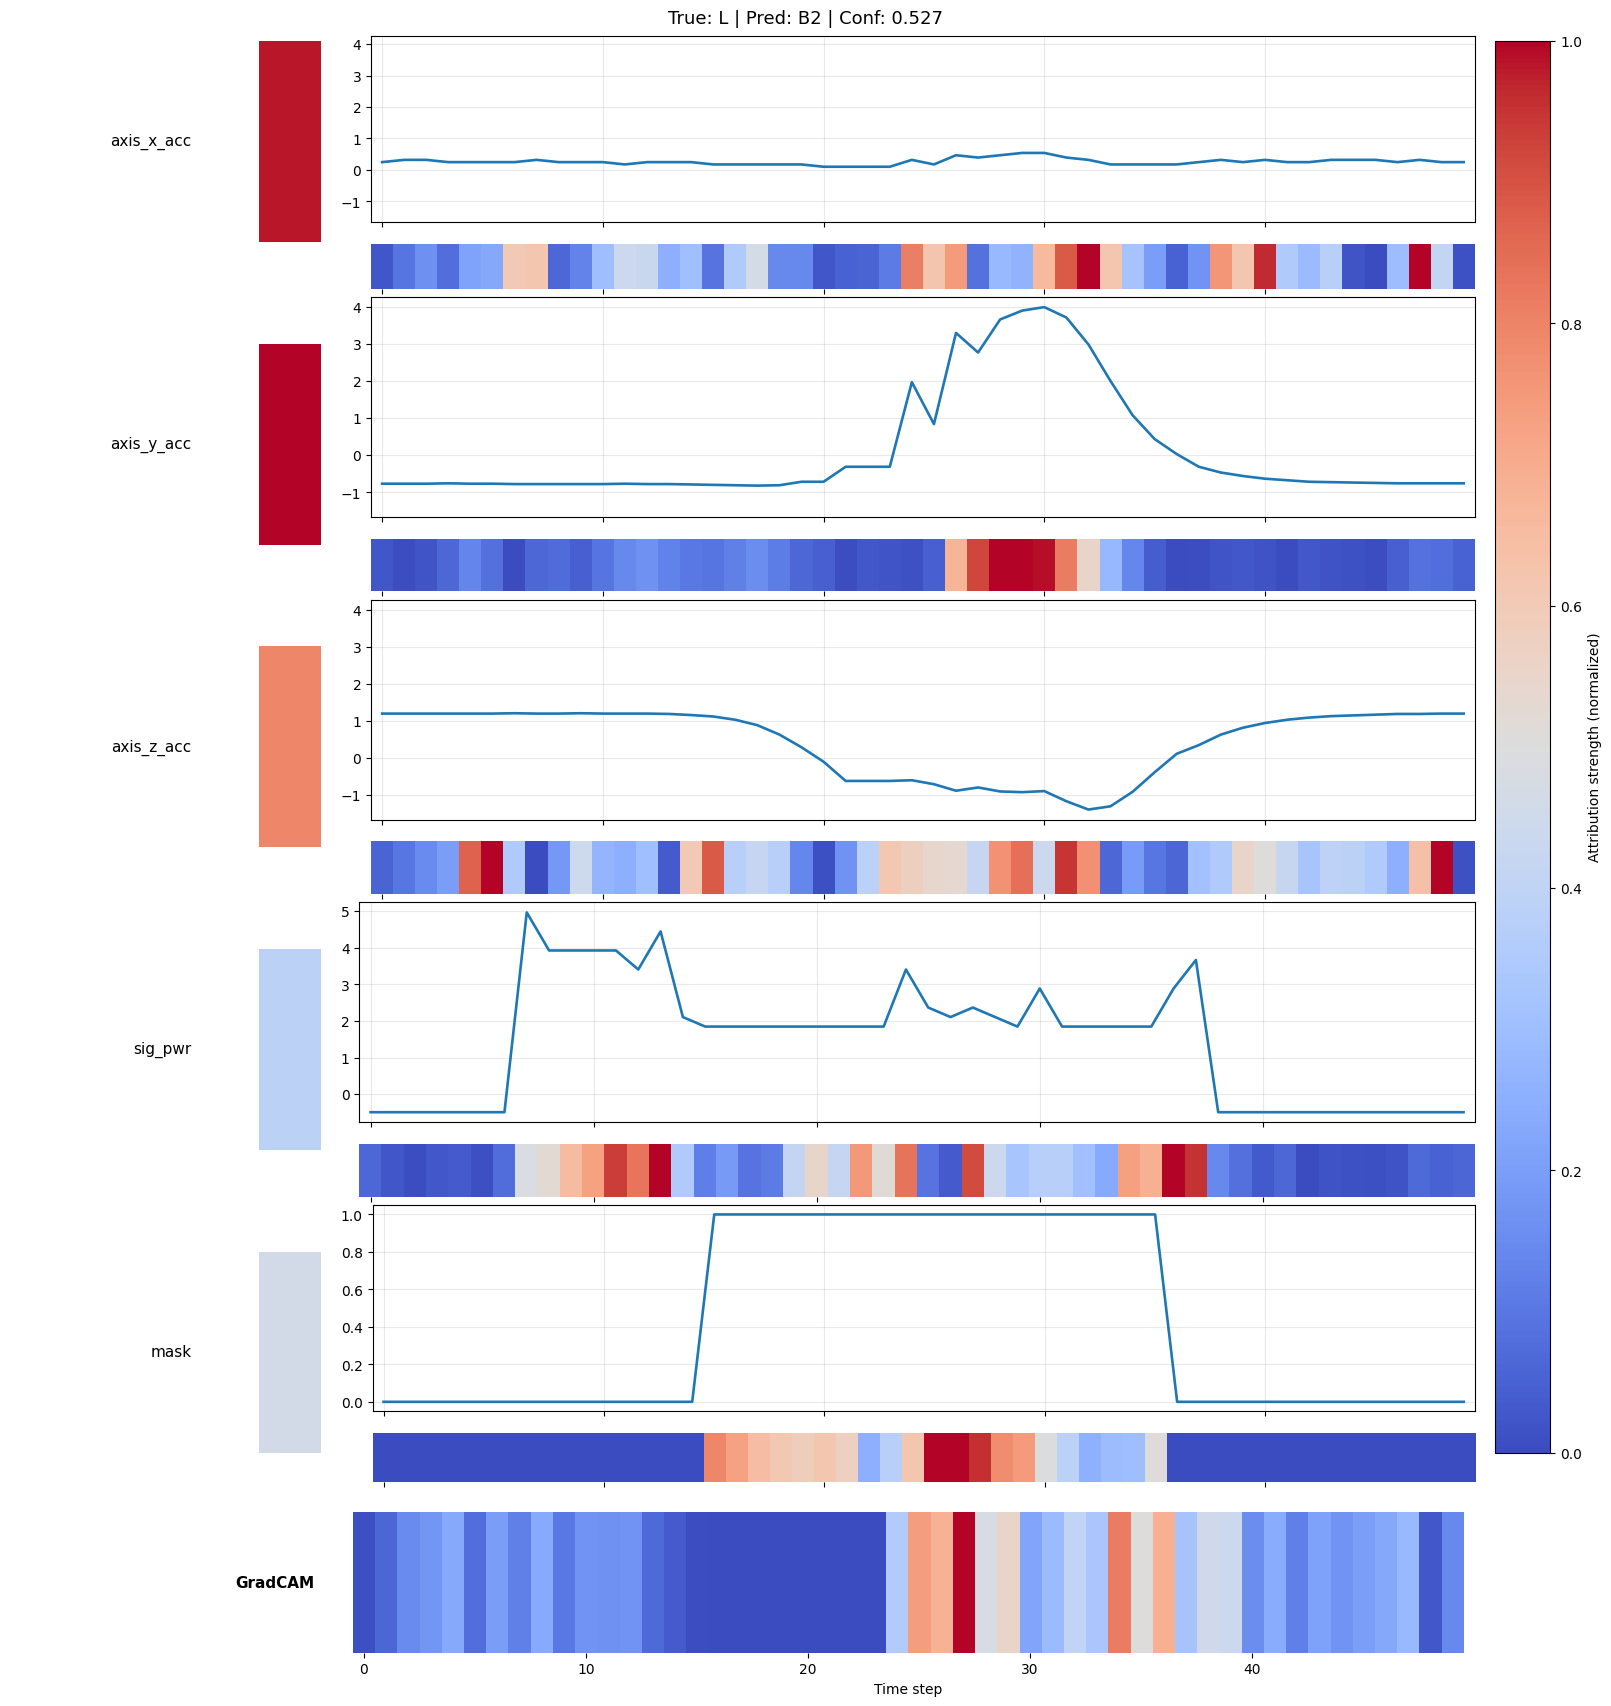

In [10]:
sample_idx = 0
sample, label = test_dataset[sample_idx]
true_label = int(torch.argmax(label).item())

result = explain_sample_with_superpixel(
    model=model,
    sample=sample,
    target_class=None,
    n_segments=24,
    compactness=0.25,
    sigma=0.8,
    occlusion_value="mean",
    mode="prob_drop",
    batch_size=32,
    keep_negative=False,
)

cam_1d, pred_class, confidence, output = compute_explanation_map(
    method="gradcam",
    model=model,
    sample=sample,
    target_layer=target_layer,
    target_class=None,
)

ig_2d, _, _, _ = compute_explanation_map(
    method="ig",
    model=model,
    sample=sample,
    target_class=pred_class,
    baseline=None,
    steps=50,
)

ig_vis = prepare_ig_for_display(ig_2d, use_abs=True, clip_percentile=98)
#ig_vis = smooth_heatmap_rows(ig_vis, kernel_size=3)

plot_time_series_explanations(
    feature_time=result["feature_time"],
    feature_scores=result["row_scores_norm"],
    feature_heatmaps=ig_vis,
    global_attribution=cam_1d,
    true_label=true_label,
    pred_class=pred_class,
    confidence=confidence,
    feature_names=FEATURE_NAMES,
    class_names=CLASS_NAMES,
    feature_cmap="coolwarm",
    heatmap_cmap="coolwarm",
    global_cmap="coolwarm",
    feature_label="Attribution strength (normalized)",
    global_title="GradCAM",
    figsize_per_feature=3.15,
)

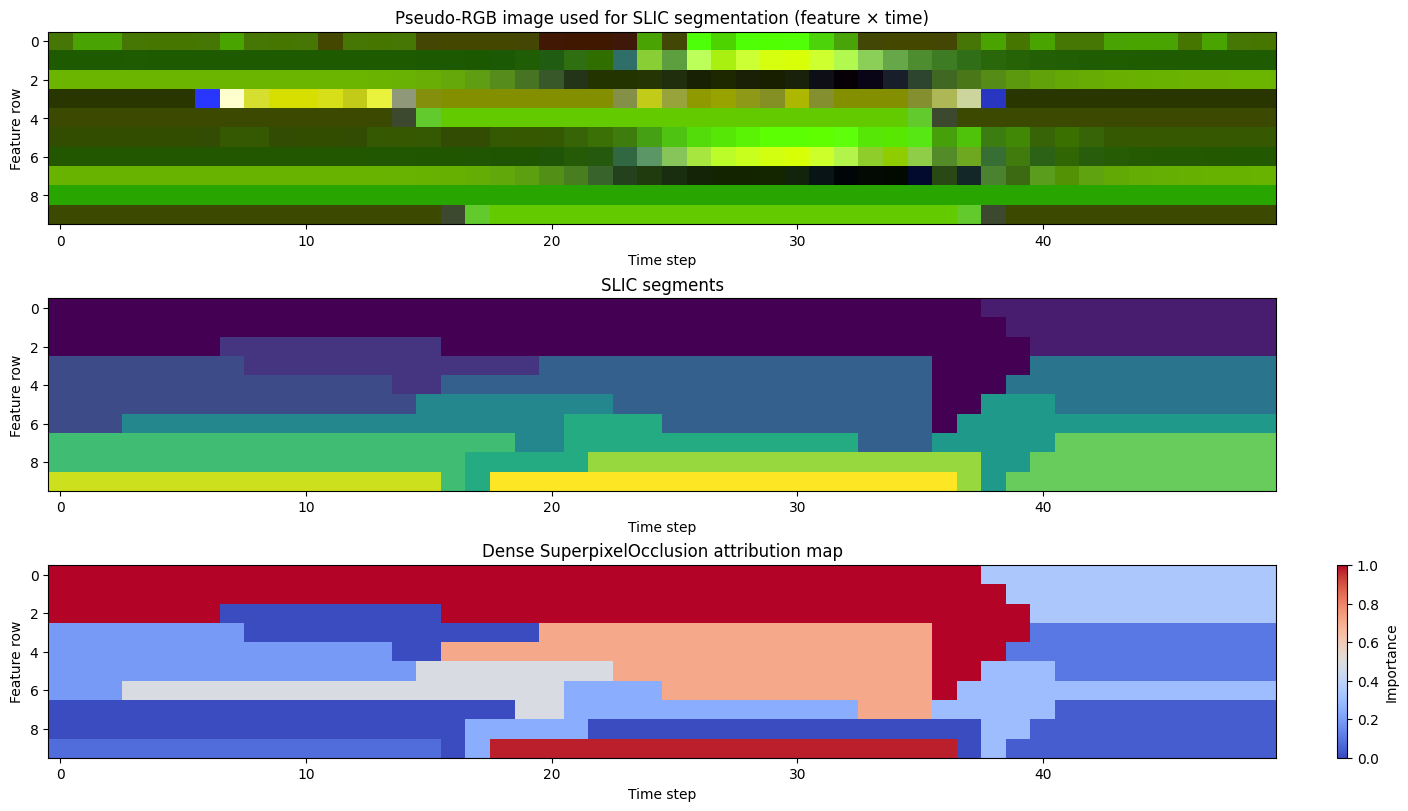

Raw row scores:
  axis_x_acc: 0.840914
  axis_y_acc: 0.854171
  axis_z_acc: 0.687428
     sig_pwr: 0.358543
        mask: 0.420255
   feature_5: 0.395390
   feature_6: 0.458285
   feature_7: 0.157654
   feature_8: 0.044611
   feature_9: 0.414531


In [11]:

plot_superpixel_debug_views(result, cmap="coolwarm")

print("Raw row scores:")
for i, s in enumerate(result["row_scores"]):
    name = FEATURE_NAMES[i] if i < len(FEATURE_NAMES) else f"feature_{i}"
    print(f"{name:>12}: {s:.6f}")


## Poznámky k interpretácii

- **Farebný štvorček pri feature** = priemerná hodnota `SuperpixelOcclusion` mapy cez celý riadok danej feature.
- Čím je štvorček svetlejší / intenzívnejší, tým viac sa daná feature v priemere podieľala na skóre vysvetľovanej triedy.
- Keďže ide o superpixelový prístup nad 2D reprezentáciou `feature × time`, výsledok je dobré chápať ako **lokálnu explanačnú aproximáciu**, nie ako úplne presnú kauzálnu mieru.
- Ak budú segmenty príliš „rozbité“, skús zmeniť hlavne:
  - `n_segments`
  - `compactness`
  - `sigma`

### Odporúčané prvé experimenty
- `n_segments=16`, `24`, `32`
- `compactness=0.1`, `0.25`, `0.5`
- `mode="prob_drop"` vs. `mode="logit_drop"`
